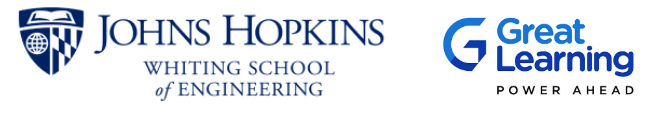

<font size=6>**Developing Agents with LangChain/LangGraph**</font>

<font size=5>**News Discovery Agent**</font>

##<font color=blue> **Business Problem - NewsFindr: AI-Powered Personalized News Discovery Agent**

NewsFindr is redefining news discovery by delivering real-time news updates tailored to user interests. Traditional search methods and generic news feeds often lead to information overload and inefficiencies, making it challenging for users to access relevant and trustworthy content efficiently.

To address this, NewsFindr leverages LangGraph agentic flow to build an AI-powered news retrieval agent that ensures accuracy and credibility. By utilizing this structured, multi-step approach, the system will provide secure, fair, and explainable recommendations—enhancing user engagement, optimizing content discovery, and improving access to timely and relevant news.

##<font color=blue>**Business Impact**
✔ **Personalized News Experience** – Delivers real-time, relevant news tailored to user interests.

✔ **Time Efficiency** – Eliminates manual searches, ensuring instant access to the latest updates.

✔ **Trust & Transparency** – Ensures accuracy, credibility, and fairness in AI-driven news recommendations.

##<font color=blue>**Objective**

🔹 **Provide real-time, personalized news retrieval** to help users discover relevant content effortlessly.

🔹 **Ensure accuracy and credibility** by sourcing news from trusted platforms and minimizing misinformation.

🔹 **Improve user engagement** through seamless content discovery, reducing information overload.

🔹 **Streamline the news consumption process** by eliminating outdated and irrelevant content, providing a refined reading experience.

##**<font color=blue>Solution Approach for "News Discovery Agent"**

<font color=Magenta>Verify User Email</font>: Check if the user's email exists in the database. If invalid, collect and store user details for future use.

<font color=Magenta>Display User Interests</font>: Retrieve and present user preferences to personalize news recommendations.

<font color=Magenta>Generate Search Queries</font>: Construct optimized search queries based on user interests to ensure relevant results.

<font color=Magenta>Retrieve Search Results</font>: Fetch real-time news articles links from multiple trusted sources.

<font color=Magenta>Extract Relevant Links</font>: Filter and select the most relevant articles aligned with the user’s topics of interest.

<font color=Magenta>Validate Authentic Sources</font>: Ensure credibility by verifying the source authority and filtering out low-quality or fake news sites.

<font color=Magenta>Provide Authenticated Links to Users</font>: Deliver only verified and high-quality news links, ensuring reliability and credibility in recommendations.

<font color=Magenta>Deploy the Agent for Members and New Users</font>: Deploy the AI-powered news retrieval agent accessible to both registered users and new members to generate interest based authenticated news links.

###🔹<font color=blue>**Optional Advanced Content**</font>

<font color=Magenta>Extract, Summarize, and Proofread Content</font>: Apply NLP techniques to generate concise, accurate summaries while maintaining content integrity.

<font color=Magenta>Provide Authenticated Links and News Summary to Users</font>: Deliver only verified and high-quality news links, ensuring reliability and credibility in recommendations.

<font color=Magenta>Deploy the Agent for Members and New Users</font>: Deploy the AI-powered news retrieval agent accessible to both registered users and new members to generate interest based authenticated news links and summary.

##**<font color=blue>Solution Workflow for "News Discovery Agent"**

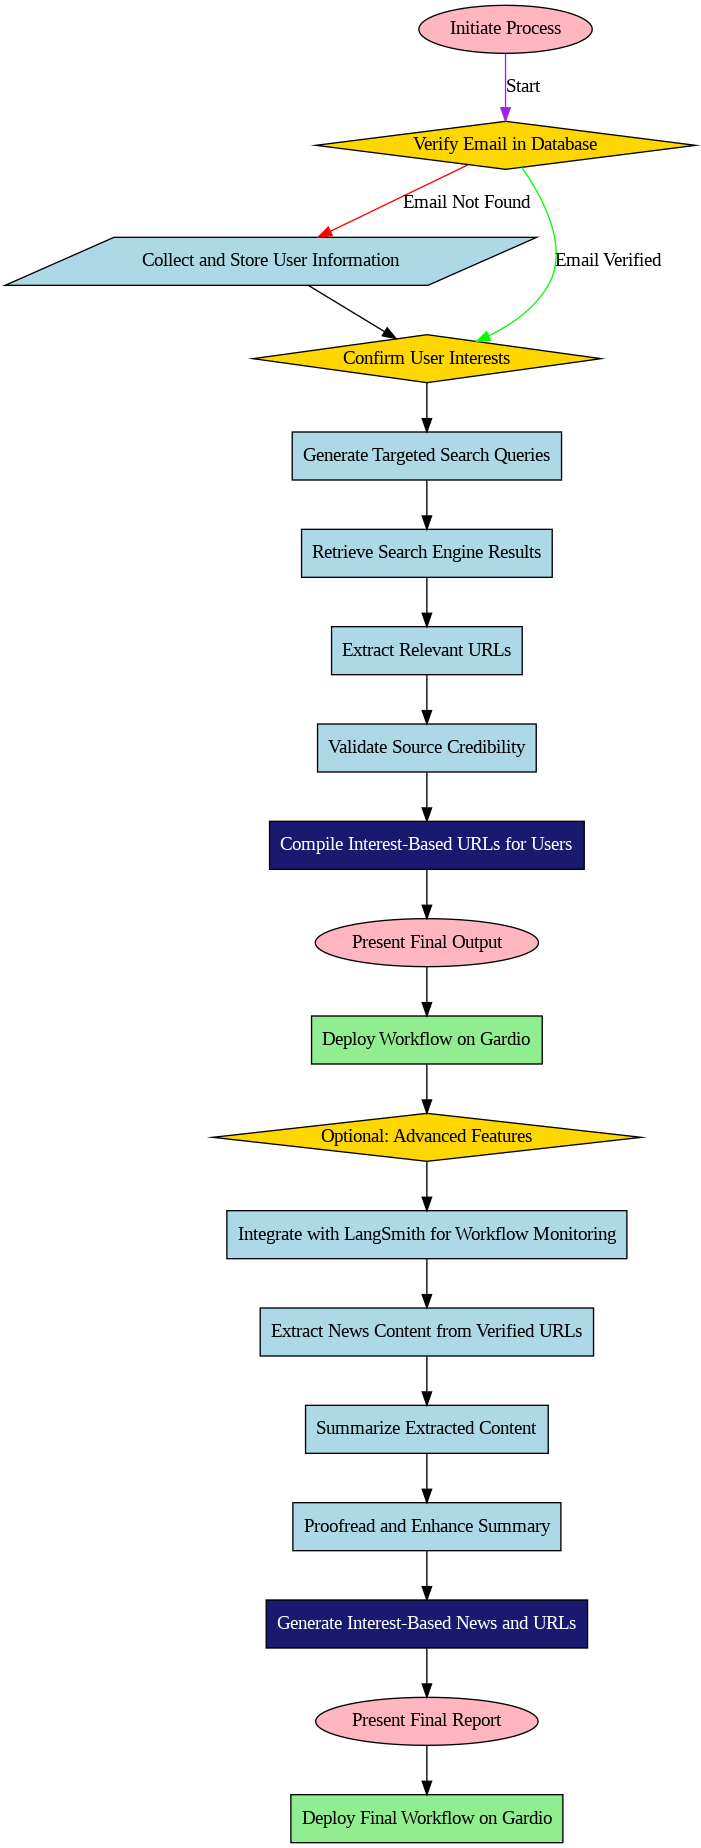

##**<font color=blue>Library Installation and LLM Calling**

In [2]:
! pip install -q openai==1.68.1 \
                 langchain \
                 langchain-openai \
                 langgraph \
                 chromadb \
                 langchain-chroma \
                 duckduckgo-search \
                 langchain_community\
                 langchain_experimental

Restart the session when prompted after installation to apply the updates

In [3]:
!pip uninstall -y numpy
!pip install numpy==1.23.5

Found existing installation: numpy 2.3.4
Uninstalling numpy-2.3.4:
  Successfully uninstalled numpy-2.3.4
  Using cached numpy-1.23.5.tar.gz (10.7 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


Before running the next cells, please restart the session. We are changing NumPy version to ensure compatibility with Gradio.

In [4]:
!pip install gradio

  Using cached numpy-2.3.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
Using cached numpy-2.3.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.4 which is incompatible.
cupy-cuda12x 13.3.0 requires numpy<2.3,>=1.22, but you have numpy 2.3.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.3.4 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.3.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you 

In [5]:
!pip show langgraph

Name: langgraph
Version: 1.0.1
Summary: Building stateful, multi-actor applications with LLMs
Home-page: 
Author: 
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: langchain-core, langgraph-checkpoint, langgraph-prebuilt, langgraph-sdk, pydantic, xxhash
Required-by: 


In [6]:
import os
import re
import json
import uuid
import logging
import sqlite3
import requests
import time
import random
from bs4 import BeautifulSoup
from typing import List, Optional, Dict

from pydantic import BaseModel, Field, ValidationError
from duckduckgo_search import DDGS

from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain.memory import ConversationBufferMemory
from langchain.sql_database import SQLDatabase
from langchain.tools import QuerySQLDataBaseTool, tool
from langchain_experimental.sql import SQLDatabaseChain
from langchain.agents import initialize_agent, create_sql_agent, AgentType
from langgraph.graph import END,StateGraph
import langgraph
from langchain_core.runnables.config import RunnableConfig
# from langgraph.channels.base import AddableValuesDict
# from langgraph.channels.base import AddableValuesDict
from langchain_core.runnables.utils import AddableDict as AddableValuesDict

import gradio as gr

from langsmith import traceable, Client


langgraph_config = RunnableConfig(recursion_limit=100,run_tree=True)

# Logging configuration
logging.basicConfig(level=logging.INFO)

In [7]:
file_name = '/content/config.json'  #paste path here
with open(file_name, 'r') as file:
    config = json.load(file)
    API_KEY = config.get("API_KEY") # Loading the API Key
    OPENAI_API_BASE = config.get("OPENAI_API_BASE") # Loading the API Base Url

In [8]:
# Importing the GPT-4 LLM and setting it up
os.environ['OPENAI_API_KEY']= API_KEY
os.environ["OPENAI_API_BASE"] = OPENAI_API_BASE ;

Initializes OpenAI's GPT-4o-mini model with different temperature settings.

**llm_high (temperature=0.7)** generates more creative and varied responses.

**llm_low (temperature=0)** ensures deterministic and consistent outputs.

In [9]:
# 🔹 Initialize OpenAI model
llm_high = ChatOpenAI(model_name="gpt-4o-mini", temperature=0.7)     #LLM to generate
llm_low = ChatOpenAI(model_name="gpt-4o-mini", temperature=0)

##**<font color=blue>Checking LLMs response**

A low temperature setting ensures consistent and repeatable responses, making the output more deterministic. It is ideal for tasks requiring accuracy, such as fact-based queries, structured data extraction, and rule-based decision-making.

In [10]:
for i in range(10):
  response = llm_low.predict("Hello, how are you?")
  print(response)

/tmp/ipython-input-2819725388.py:2: LangChainDeprecationWarning: The method `BaseChatModel.predict` was deprecated in langchain-core 0.1.7 and will be removed in 1.0. Use :meth:`~invoke` instead.
  response = llm_low.predict("Hello, how are you?")


Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?
Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?
Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?
Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?
Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?
Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?
Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?
Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?
Hello! I'm just a program, so I don't have feelings, but I'm her

A high temperature setting introduces more randomness and variability in responses, making the output creative and diverse. It is useful for tasks like brainstorming, storytelling, content generation, and exploring multiple perspectives.

In [11]:
for i in range(10):
  response = llm_high.predict("Hello, how are you?")
  print(response)

Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?
Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?
Hello! I'm just a computer program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?
Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?
Hello! I'm just a computer program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?
Hello! I'm just a computer program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?
Hello! I'm just a computer program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?
Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?
Hello! I'm just a program, s

##<font color=blue>**Defining the State Schema for LangGraph Workflow**
It establishes a structured state schema to manage data flow across nodes, ensuring seamless transitions and efficient execution within the LangGraph workflow.

In [12]:
# class CustomerState(BaseModel):
#     email: Optional[str] = None
#     name: Optional[str] = None
#     interests: Optional[str] = None
#     email_found: bool = False
#     customer_id: Optional[str] = None
#     expanded_search: List[str] = []
#     search_results: List[Dict[str, str]] = []
#     credible_urls: List[Dict[str, str]] = []
#     max_results: int = 7
#     #filtered_urls: List[Dict[str, str]] = []
#     info: List[str] = []

from typing import Optional, List, Dict
from pydantic import BaseModel

class CustomerStateV2(BaseModel):
    email: Optional[str] = None
    name: Optional[str] = None
    interests: Optional[str] = None
    email_found: bool = False
    customer_id: Optional[str] = None
    expanded_search: List[str] = []
    search_results: List[Dict[str, str]] = []
    credible_urls: List[Dict[str, str]] = []
    max_results: int = 7
    filtered_urls: List[Dict[str, str]] = []
    info: List[Dict[str, str]] = Field(default_factory=list)


In [13]:
test_data = {
    "filtered_urls": [
        {"url": "https://www.msn.com"},
        {"url": "https://www.economist.com"}
    ]
}

state = CustomerStateV2(**test_data)
print(state)


email=None name=None interests=None email_found=False customer_id=None expanded_search=[] search_results=[] credible_urls=[] max_results=7 filtered_urls=[{'url': 'https://www.msn.com'}, {'url': 'https://www.economist.com'}] info=[]


In [14]:
state

CustomerStateV2(email=None, name=None, interests=None, email_found=False, customer_id=None, expanded_search=[], search_results=[], credible_urls=[], max_results=7, filtered_urls=[{'url': 'https://www.msn.com'}, {'url': 'https://www.economist.com'}], info=[])

class CustomerState(BaseModel):
    email: Optional[str] = None
    name: Optional[str] = None
    interests: Optional[str] = None
    email_found: bool = False
    customer_id: Optional[str] = None
    expanded_search: List[str] = []
    search_results: List[Dict[str, str]] = []
    credible_urls: List[str] = []
    max_results: int = 7
    filtered_urls: List[str] = []
    info: List[str] = []

##<font color=blue>**SQL Agent for Data Retrieval and Customer Information Update**
Facilitates efficient data retrieval and modification, enabling seamless customer information management through SQL interactions

<font color=magenta>**Function setup_sql_agent**</FONT>: Initializes an AI-powered SQL agent for querying and updating a database.
It connects to an SQLite database, defines a system message for structured interactions, and sets up an agent using a zero-shot approach with conversation memory for better context handling

In [15]:
# 🔹 Initialize SQL Agent with System Message
def setup_sql_agent():
    db = SQLDatabase.from_uri("sqlite:///customer.db")

    system_message = """You are an AI-powered SQL assistant. Your role is to retrieve or insert structured data into the database efficiently and accurately. And return no result found if not able to retrieve data."""

    # Define SQL Query Tool
    sql_tool = QuerySQLDataBaseTool(db=db)

    # Initialize agent with system message
    sql_agent = initialize_agent(
        tools=[sql_tool],
        llm=llm_low,
        agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION,
        verbose=True,
        memory=ConversationBufferMemory(),
        system_message=system_message.strip()  # Pass system message to agent
    )

    return sql_agent

<font color=blue>**Email Retrieval and Validation in Customer State**

Checks if the user's email is available in the state. If missing, prompts the user to enter their email, ensures it's in lowercase, and updates the state with the provided email.

In [16]:
def ask_email(state: CustomerStateV2):
    """Retrieve email from state or prompt user if missing."""
    if not state.email:
        state.email = input("Enter your email ID: ").strip().lower()

    return {"email": state.email}

##<font color=blue>**Customer Email Verification and Data Retrieval**

This function, check_email, queries a database using the provided email ID to check if the customer exists. It extracts the customer's ID, Name, Email, and Interests. If no matching record is found, it sets email_found to False.

**Function Breakdown:**

Database Query Execution:

Constructs a query to fetch customer details.

Calls sql_agent.run(query) to execute the query.

Handling Missing Records:

Checks if the response contains "no result found" using regex.

If no record exists, it updates state.email_found = False.

Extracting Customer Details:

Interests: Extracted from the response if present.

Email: Retrieved using regex.

Name: Extracted separately and assigned to the state.

Updating State Variables:

Updates state.name, state.interests, and state.email_found = True if details are found.

Error Handling:

Catches JSON decoding errors or type errors while parsing responses.

Logs errors and ensures email_found is set to False in case of failures.

This function ensures that customer data is correctly fetched and stored in the system state before proceeding with further actions.

In [17]:
def check_email(state: CustomerStateV2):
    """
    Queries the database for customer details using the provided email ID.
    Extracts ID, Name, Email, and Interests. If no result is found, email_found is set to False.
    """
    query = f"""
    Extract ID, Name, Email, and Interests information from the database for the email ID '{state.email}'.
    Always return responses with the following fields:
    - ID
    - Name
    - Email
    - Interests
    return no result found if not able to retreive data
    """

    # Execute query and strip result
    sql_agent = setup_sql_agent()
    result = sql_agent.run(query)

    # Early exit if no result found
    match = re.search(r"\bno\s+(result|results|record|records)\b", result, re.IGNORECASE)

    if match :
        state.email_found = False
        return {"email_found": False}
    interests_match = re.search(r"Interests:\s*(.+)", result)
    interests = [i.strip() for i in interests_match.group(1).split(",")] if interests_match else []

    # Extract email first
    email_match = re.search(r"Email:\s*([\w\.-]+@[\w\.-]+)", result)

    # Only proceed if we found a valid email
    email = email_match.group(1)

    # Extract interests
    interests_match = re.search(r"Interests:\s*(.+)", result)
    interests = [i.strip() for i in interests_match.group(1).split(",")] if interests_match else []

    try:
        # Extract name
        name_match = re.search(r"Name:\s*(.+)", result)
        name = name_match.group(1).strip() if name_match else None

        # Update state
        state.name = name
        state.interests = ', '.join(interests)
        state.email_found = True

        return {
            "email_found": True,
            "name": state.name,
            "interests": state.interests
        }

    except (json.JSONDecodeError, TypeError) as e:
        logging.error(f"Failed to parse customer data: {result} - Error: {str(e)}")
        state.email_found = False
        return {"email_found": False}

##<font color=blue>**New Customer Registration and Unique ID Generation**

This function handles new customer registration when their email is not found in the database. It assigns a unique customer ID and collects missing details such as name and interests before inserting the data into the database.

**Function Breakdown:**

**Generate a Unique Customer ID:**

generate_customer_id() creates a 10-character uppercase unique ID using uuid.uuid4(). This is done for new user.

**Prompt New User for Details:**

If the email is not found in database, the system asks for the customer's name.

Ensures at least one interest is selected before proceeding.

Format Interests for Storage:

Converts the comma-separated interests into a clean list.

Ensures at least one interest is provided before proceeding.

Insert Data into the Database:

Constructs an SQL INSERT query to store the customer ID, name, email, and interests.

Executes the query using sql_agent.run(query).

Update State and Return Confirmation:

Marks email_found = True, ensuring the system recognizes the user in future interactions.

Returns the customer ID, name, and interests for further processing.

This function ensures seamless onboarding of new customers by generating a unique ID, collecting essential details, and securely storing them in the database.

In [18]:
# Ask for name and interests if email not found, generate customer id and add in database
def ask_and_add_details(state: CustomerStateV2):
  # Generate a unique customer ID
    def generate_customer_id():
        return str(uuid.uuid4())[:10].upper()
    print("Your email is not in the database.")
    if not state.name:
       name = input("Enter your name: ").strip()
    else:
      name=state.name
    customer_id = generate_customer_id()

    while True:
        if not state.interests:
          interests = input(f"Select at least one interest (comma-separated): ").strip()
        else:
          interests=state.interests
        embed_interests = [i.strip() for i in interests.split(",")]
        if embed_interests:
            break
        print("❌ Please Enter at least one interest.")

    query = f"""INSERT INTO customers (customer_id, name, email, interests)
                VALUES ('{customer_id}', '{name}', '{state.email}', '{embed_interests}')"""
    sql_agent = setup_sql_agent()

    sql_agent.run(query)

    return {"email_found": True, "customer_id": customer_id, "name": name, "interests": interests}

<font color=blue>**Displaying Customer Interests**

In [19]:
# Show interests
def show_interests(state: CustomerStateV2):
    interests_str = state.interests
    return {"message": f"Hello {state.name}, your interests are {interests_str}."}

##<font color=blue>**Generating Expanded Search Queries for Current News**

Generating Expanded Search Queries for Current News
This function, expand_search_queries, generates precise and up-to-date search queries based on the user's interests. It ensures that each query is crafted to retrieve breaking news, trending topics, or recent developments without relying on specific years.

The function takes user interests from state.interests, splits them into individual topics, and processes each through an LLM (low-temperature model) to generate a relevant search query.

A system prompt guides the model to focus only on current events and avoid outdated information.

The expanded search queries are stored in expanded_search and returned for later use in retrieving news articles.

**A low-temperature model (llm_low, temperature = 0) is the better choice here because:**

✅ **Consistency & Precision** – Ensures that the expanded search queries are deterministic and consistently structured for reliable news retrieval.

✅ **Avoiding Random Variations** – Since search queries need to be precise and relevant, high temperature could introduce unnecessary creativity or ambiguity.

✅ **Reproducibility** – The same input interests will always generate predictable queries, preventing irrelevant or overly diverse results.

If the goal were more diverse or exploratory queries, a higher temperature (e.g., 0.7) could be used. But for structured and accurate search expansion, low temperature is ideal.

In [20]:
def expand_search_queries(state: CustomerStateV2):
    """
    Use the core LLM to expand each user interest into a related search query.
    """
    print("---EXPAND SEARCH QUERIES---")


    system_prompt = f"""You are an expert news analyst specializing in crafting precise search queries to retrieve the most recent, up-to-date information.
            Your task is to generate one **relevant and time-sensitive** search query for each provided interest, ensuring the results focus on **breaking news, trending topics, or recent developments** only.

            - Do **not** include any specific year in the query.
            - Format queries to prioritize **current news** while avoiding outdated information.
            - Ensure the queries remain natural and relevant without relying on explicit date mentions."""


    expanded_queries = []
    mid_interest = state.interests
    interests = mid_interest.split(', ')
    for interest in interests:
        prompt = f"Generate one search query related to: '{interest}'"

        response = llm_low.invoke(
            [
                SystemMessage(content=system_prompt),
                HumanMessage(content=prompt)
            ]
        )

        query = response.content.strip()
        if query:
            expanded_queries.append(query)

    print("Expanded Search Queries:\n", expanded_queries)

    return {"expanded_search": expanded_queries}

**Sanitize Search Queries by Removing Special Characters**

In [21]:
def clean_text(text):
    # Remove special characters and extra whitespace
    cleaned = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return ' '.join(cleaned.split())

##<font color=blue>**Fetch News Results Using DuckDuckGo**
**Function Explanation:**

This function retrieves news results from DuckDuckGo based on the user's expanded search queries.

Cleans the queries before sending them to DuckDuckGo.

Skips invalid queries to ensure only valid ones are processed.

Performs a news search for each cleaned query using the DuckDuckGo Search (DDGS) library.

Ensures at least 5 results by running multiple search attempts if necessary.

Avoids blocked queries by checking if results contain unwanted URLs like Google.

Implements a delay (2-5 seconds) between searches to avoid API restrictions.

Returns a dictionary containing all collected search results.

In [22]:
def get_duckduckgo_results(state: CustomerStateV2):
    print("---GETTING DUCKDUCKGO RESULTS---")
    search_results = []

    for query in state.expanded_search:
        # Clean both query
        clean_query = clean_text(query)

        # Skip if either is empty after cleaning
        if  not clean_query:
            print(f"Skipping invalid pair: { query}")
            continue

        print(f"🔍 Searching for: {clean_query}")

        with DDGS() as ddgs:
          while len(search_results) < 5:
            results = list(ddgs.news(clean_query, max_results=state.max_results))
            print(f"Raw Response for '{clean_query}': {results}")

            if not results or any("google.com" in r.get("url", "") for r in results):
                print(f"⚠️ Warning: Potential API issue or DuckDuckGo blocking request for '{clean_query}'.")
                continue

            search_results.extend(results)

            wait_time = random.uniform(2, 5)
            print(f"⏳ Waiting {wait_time:.2f} seconds before next request...")
            time.sleep(wait_time)

    print(search_results)
    return {"search_results": search_results}

##<font color=blue>**Filter Relevant URLs Based on User Interests**
**Function Explanation:**

This function filters search result URLs to keep only those relevant to the user's interests.

Extracts URLs and their body content from the search results.

Creates a prompt to instruct an LLM (low-temperature model) to filter URLs based on user interests.

Uses an AI model to return only URLs that match at least one interest.

Cleans the AI-generated response to remove unnecessary characters.

Maps the filtered URLs back to their corresponding body content.

Updates the state with the refined list of relevant URLs and their descriptions.

In [23]:
def filter_urls(state: CustomerStateV2):
    """
    Filters URLs based on user interests and includes the associated body content in the output.
    """
    print("---FILTER RELEVANT URLS---")

    urls = []
    body_map = []  # Mapping of URL to its body content

    for result in state.search_results:
        urls.append(result['url'])
        body_map.append(result['body'])

    # Create the prompt with properly formatted URLs
    prompt = (
        "Identify and retain only the URLs that are relevant to one or more of the user's interests from the following list:\n\n"
        f"User Interests: {', '.join(state.interests)}\n\n"
        "URLs to filter:\n"
        + "\n".join(urls) + "\n\n"
        "Return only a list of relevant URLs without any explanation."
    )

    system_prompt = (
        "You are an expert in filtering search results. Your task is to extract only the URLs that match at least one of the user's interests, ensuring relevance to their request."
    )

    response = llm_low.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=prompt)
    ])

    # Clean the response by removing brackets and quotes
    filtered_results = response.content.strip()
    filtered_results = filtered_results.replace('[', '').replace(']', '').replace("'", '')
    filtered_results = [url.strip() for url in filtered_results.split('\n') if url.strip()]

    # Create output with URLs and associated body content
    filtered_urls = [{"url": filtered_results[i], "body": body_map[i]} for i in range(len(filtered_results))]
    state.filtered_urls=filtered_urls
    return {"filtered_urls": filtered_urls}

##<FONT COLOR=BLUE>**Filter Trustworthy News Sources**
**Function Explanation:**
This function evaluates the credibility of news URLs and filters out unreliable sources.

Extracts URLs and their body content from the previously filtered results.

Uses a system prompt to instruct the LLM to analyze the credibility of the URLs.

Sends a prompt to the LLM asking it to return only the trustworthy URLs.

Processes the response by cleaning and formatting the output.

Maps the credible URLs back to their corresponding body content.

Returns a refined list of trustworthy URLs for further analysis or display.

In [24]:
def analyze_news_url(state: CustomerStateV2):
    """Asks GPT to analyze if a URL is trustworthy."""
    print("---FILTER TRUSTWORTHY URLS---")
    urls = []
    body_map = []  # Mapping of URL to its body content

    for result in state.filtered_urls:
        urls.append(result['url'])
        body_map.append(result['body'])

    system_prompt = """You are a news credibility expert. Analyze if the given news URL belongs to a trustworthy source based on safety standards."""

    prompt = (
    "Analyze the credibility of the following news sources. "
    "Identify which URLs are trustworthy.\n\n"
    "URLs to evaluate:\n"
    + "\n".join(urls) +
    "\n\nReturn only a list of credible URLs without any explanation.")

    response = llm_low.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=prompt) ])
    # Clean the response by removing brackets and quotes
    credible_results = response.content.strip()
    credible_results = credible_results.replace('[', '').replace(']', '').replace("'", '')
    credible_results = [url.strip() for url in credible_results.split('\n') if url.strip()]

    # Create output with URLs and associated body content
    credible_urls = [{"url": credible_results[i], "body": body_map[i]} for i in range(len(credible_results))]
    print(credible_urls)
    return {"credible_urls": credible_urls}

##<font color=blue>**Display Final Verified URLs**

In [25]:
def print_url(state: CustomerStateV2):
    print("---FINAL url---")
    for result in state.credible_urls:
        print(result['url'])
        print("\n")  # Print blank line

##<font color=blue>**Customer Interest-Based News Url Retrieval Workflow**

In [26]:
# Initialize the customer state object to store user details and workflow progress
initial_state = CustomerStateV2()

# Initialize LangGraph workflow with the defined state schema
workflow = StateGraph(state_schema=CustomerStateV2)

# Step 1: Collect user email and preferences
workflow.add_node("ask_email", ask_email)  # Prompt user for their email
workflow.add_node("check_email", check_email)  # Check if the email exists in the database
workflow.add_node("ask_and_add_details", ask_and_add_details)  # Collect name and interests if email is not found
workflow.add_node("show_interests", show_interests)  # Display the user's interests

# Step 2: Expand search queries based on user interests
workflow.add_node("expand_search_queries", expand_search_queries)  # Generate refined search queries

# Step 3: Fetch search results from DuckDuckGo
workflow.add_node("get_duckduckgo_results", get_duckduckgo_results)  # Retrieve news articles based on search queries

# Step 4: Filter URLs to keep only relevant ones
workflow.add_node("filter_urls", filter_urls)  # Select URLs relevant to the user's interests

# Step 5: Filter URLs to keep only authentic ones
workflow.add_node("analyze_news_url", analyze_news_url)  # Check the credibility of news sources

# Step 6: Print url
workflow.add_node("print_url", print_url)  # Display the final summarized information

# Define Workflow Transitions
workflow.set_entry_point("ask_email")  # Start the workflow by asking for email

# Transition from asking email to checking if it's in the database
workflow.add_edge("ask_email", "check_email")

# If the email is found, show interests; otherwise, ask for details and then show interests
workflow.add_conditional_edges(
    "check_email",
    lambda result: "show_interests" if result.email_found else "ask_and_add_details"
)

# After collecting details, display user interests
workflow.add_edge("ask_and_add_details", "show_interests")

# Expand search queries based on the collected interests
workflow.add_edge("show_interests", "expand_search_queries")

# Fetch search results using DuckDuckGo
workflow.add_edge("expand_search_queries", "get_duckduckgo_results")

# Filter search results to keep only relevant URLs
workflow.add_edge("get_duckduckgo_results", "filter_urls")

# Analyze news URLs to ensure credibility
workflow.add_edge("filter_urls", "analyze_news_url")

# Print the final output after summarizing content
workflow.add_edge("analyze_news_url", "print_url")

# Set the final output step as the end of the workflow
workflow.add_edge("print_url", END)

# Compile and execute the workflow
graph = workflow.compile()


**Execute Workflow for existing user**

Email ids to use : alice.6eb33c45-5@gmail.com

In [27]:
response = graph.invoke(initial_state, langgraph_config)

Enter your email ID: alice.6eb33c45-5@gmail.com


/tmp/ipython-input-3631347512.py:8: LangChainDeprecationWarning: The class `QuerySQLDataBaseTool` was deprecated in LangChain 0.3.12 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-community package and should be used instead. To use it run `pip install -U :class:`~langchain-community` and import as `from :class:`~langchain_community.tools import QuerySQLDatabaseTool``.
  sql_tool = QuerySQLDataBaseTool(db=db)
/tmp/ipython-input-3631347512.py:16: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  memory=ConversationBufferMemory(),
/tmp/ipython-input-3631347512.py:11: LangChainDeprecationWarning: LangChain agents will continue to be supported, but it is recommended for new use cases to be built with LangGraph. LangGraph offers a more flexible and full-featured framework for building agents, including support for tool-calling, persistence of state, and human-in-the-loo



> Entering new AgentExecutor chain...
I need to construct a SQL query to extract the required information (ID, Name, Email, and Interests) from the database for the specified email address. I will assume the relevant table is named "users" and contains the necessary fields.

Action: 
sql_db_query

Action Input: 
```sql
SELECT ID, Name, Email, Interests 
FROM users 
WHERE Email = 'alice.6eb33c45-5@gmail.com';
```

Observation: Error: (sqlite3.OperationalError) near "```sql
SELECT ID, Name, Email, Interests 
FROM users 
WHERE Email = 'alice.6eb33c45-5@gmail.com';
```": syntax error
[SQL: ```sql
SELECT ID, Name, Email, Interests 
FROM users 
WHERE Email = 'alice.6eb33c45-5@gmail.com';
```
]
(Background on this error at: https://sqlalche.me/e/20/e3q8)
Thought:I see that there was a syntax error in my SQL query due to the incorrect formatting of the SQL code. I need to remove the unnecessary backticks and format the query correctly.

Action: 
sql_db_query

Action Input: 
```sql
SELECT ID,

/tmp/ipython-input-4004244532.py:16: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use time

Raw Response for 'latest political developments and breaking news': [{'date': '2025-10-30T04:57:00+00:00', 'title': 'Government shutdown continues as senators express cautious optimism about talks', 'body': 'Senate Majority Leader John Thune said talks among rank-and-file senators aimed at ending the government shutdown have ramped up.', 'url': 'https://www.cbsnews.com/live-updates/government-shutdown-latest-snap-benefits-impasse/', 'image': 'https://assets3.cbsnewsstatic.com/hub/i/r/2025/10/29/3eb85981-b306-4de2-9ea3-6c9f5719351f/thumbnail/1200x630g2/46a102bb10d8360787eaadd9bf2109fb/gettyimages-2243474452.jpg', 'source': 'CBS News'}, {'date': '2025-10-23T13:13:09+00:00', 'title': '11Alive News: The Take | Alice Barr on latest developments from Washington (10/23/25)', 'body': 'NBC News correspondent Alice Barr joins live from Washington with the latest political headlines shaping the national conversation.', 'url': 'https://www.msn.com/en-us/news/other/11alive-news-the-take-alice-barr-

...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---FILTER TRUSTWORTHY URLS---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

[{'url': '1. https://www.economist.com/united-states/2025/10/25/checks-and-balance-newsletter-rural-america-reckons-with-donald-trump', 'body': 'Senate Majority Leader John Thune said talks among rank-and-file senators aimed at ending the government shutdown have ramped up.'}, {'url': '2. https://www.nbcnews.com/politics/justice-department/experts-fear-impact-deepening-polarization-perceived-political-prosecu-rcna233975', 'body': 'NBC News correspondent Alice Barr joins live from Washington with the latest political headlines shaping the national conversation.'}, {'url': '3. https://www.cnn.com/2025/09/26/politics/disengaged-voters-us-elections', 'body': 'A nationwide string of threats and violent acts present a problem experts say is politically more complex than it seems.'}]
---FINAL url---
1. https://www.economist.com/united-states/2025/10/25/checks-and-balance-newsletter-rural-america-reckons-with-donald-trump


2. https://www.nbcnews.com/politics/justice-department/experts-fear-im

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

##<font color=blue>**Generating Final Function**

In [28]:
import logging
import sys
import os
import builtins

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [29]:
def extract_url_list(addable_dict: AddableValuesDict):
    # Extract URLs and content from the 'credilbe_url' section
    return [{"url": credible_url.get("url", ""), "content": credible_url.get("content", "")}
            for credible_url in addable_dict.get("credible_urls", [])]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [30]:
def url_generation_with_agent(email: str,name: str=None,interests:str=None):
    """Starts the workflow with a provided email."""
    # Ensure email is passed correctly to CustomerState
    # Create an instance of CustomerState with email
    def suppress_logs():
        """Disables all logging, print statements, and standard output."""
        logging.basicConfig(level=logging.WARNING, force=True)

        # Silence specific noisy loggers
        for noisy_logger in ["sql agent", "duckduck go search"]:
            logging.getLogger(noisy_logger).setLevel(logging.ERROR)

        # Redirect stdout and stderr to prevent any unwanted print output
        sys.stdout = open(os.devnull, "w")
        sys.stderr = open(os.devnull, "w")

        # Disable print statements
        builtins.print = lambda *args, **kwargs: None

    # Call this function at the start to suppress logs
    suppress_logs()

    initial_state = CustomerStateV2(email=email,name=name,interests=interests)

    # Initialize LangGraph workflow with the defined state schema
    workflow = StateGraph(state_schema=CustomerStateV2)

    # Step 1: Collect user email and preferences
    workflow.add_node("ask_email", ask_email)  # Prompt user for their email
    workflow.add_node("check_email", check_email)  # Check if the email exists in the database
    workflow.add_node("ask_and_add_details", ask_and_add_details)  # Collect name and interests if email is not found
    workflow.add_node("show_interests", show_interests)  # Display the user's interests

    # Step 2: Expand search queries based on user interests
    workflow.add_node("expand_search_queries", expand_search_queries)  # Generate refined search queries

    # Step 3: Fetch search results from DuckDuckGo
    workflow.add_node("get_duckduckgo_results", get_duckduckgo_results)  # Retrieve news articles based on search queries

    # Step 4: Filter URLs to keep only relevant ones
    workflow.add_node("filter_urls", filter_urls)  # Select URLs relevant to the user's interests

    # Step 5: Filter URLs to keep only authentic ones
    workflow.add_node("analyze_news_url", analyze_news_url)  # Check the credibility of news sources

    # Step 6: Print url
    workflow.add_node("print_url", print_url)  # Display the final summarized information

    # Define Workflow Transitions
    workflow.set_entry_point("ask_email")  # Start the workflow by asking for email

    # Transition from asking email to checking if it's in the database
    workflow.add_edge("ask_email", "check_email")

    # If the email is found, show interests; otherwise, ask for details and then show interests
    workflow.add_conditional_edges(
        "check_email",
        lambda result: "show_interests" if result.email_found else "ask_and_add_details"
    )

    # After collecting details, display user interests
    workflow.add_edge("ask_and_add_details", "show_interests")

    # Expand search queries based on the collected interests
    workflow.add_edge("show_interests", "expand_search_queries")

    # Fetch search results using DuckDuckGo
    workflow.add_edge("expand_search_queries", "get_duckduckgo_results")

    # Filter search results to keep only relevant URLs
    workflow.add_edge("get_duckduckgo_results", "filter_urls")

    # Analyze news URLs to ensure credibility
    workflow.add_edge("filter_urls", "analyze_news_url")

    # Print the final output after summarizing content
    workflow.add_edge("analyze_news_url", "print_url")

    # Set the final output step as the end of the workflow
    workflow.add_edge("print_url", END)

    # Compile and execute the workflow
    graph = workflow.compile()

    # Start workflow execution with initial state
    output = graph.invoke(initial_state,langgraph_config)
    final_output=extract_url_list(output)
    formatted_results = []
    for i, result in enumerate(final_output, 1):
        formatted_results.append(f"{i}. {result['url']}\n")

    return "\n".join(formatted_results)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

##<Font color=blue>**Check Function for Exisiting and New Members**

In [31]:
url_generation_with_agent("alice.6eb33c45-5@gmail.com")


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

'1. 1. https://www.cbsnews.com/live-updates/government-shutdown-latest-snap-benefits-impasse/\n\n2. 2. https://www.economist.com/united-states/2025/10/25/checks-and-balance-newsletter-rural-america-reckons-with-donald-trump\n\n3. 3. https://www.nbcnews.com/politics/justice-department/experts-fear-impact-deepening-polarization-perceived-political-prosecu-rcna233975\n\n4. 4. https://www.cnn.com/2025/09/26/politics/disengaged-voters-us-elections\n'

In [32]:
url_generation_with_agent("richa@example.com","Richa","Health")

'1. https://www.msn.com/en-us/health/health-news/shingles-vaccine-connected-to-exciting-health-benefits-in-large-study/ar-AA1Pgp1d\n\n2. https://www.msn.com/en-us/health/other/health-secretary-kennedy-says-theres-not-sufficient-proof-to-show-tylenol-causes-autism/ar-AA1Psbbu\n\n3. https://www.msn.com/en-us/health/other/when-it-comes-to-walking-for-health-longer-is-better-study-suggests/ar-AA1Piz8Z\n\n4. https://www.msn.com/en-us/health/other/tuesdays-daily-dose-of-health-news-with-monica-robins-new-cpr-guidelines-and-study-shows-mrna-vaccines-help-cancer-survival/ar-AA1PmM1I\n\n5. https://www.msn.com/en-us/money/other/fda-to-streamline-approvals-for-generic-biological-drugs-in-latest-move-targeting-health-costs/ar-AA1PrjtK\n\n6. https://www.msn.com/en-us/money/insurance/what-to-know-as-the-annual-sign-up-window-for-health-insurance-arrives/ar-AA1Pqdak\n'

##<Font color=blue>**Deployment with Gradio**

In [33]:
with gr.Blocks() as iface:
    gr.Markdown("## 🔍 AI-Powered News Fetcher")

    with gr.Tabs():
        with gr.Tab("For Existing Members"):
            gr.Markdown("Enter your email id.")
            with gr.Row():
                with gr.Column(scale=1):
                    email_input_wo = gr.Textbox(label="Enter your email id", placeholder="e.g., abc@example.com")

                    with gr.Row():
                        submit_button_wo = gr.Button("Submit", variant="primary")
                        cancel_button_wo = gr.Button("Cancel", variant="stop")

                with gr.Column(scale=2):
                    output_wo = gr.Textbox(label="Latest News", interactive=False)

            submit_button_wo.click(fn=url_generation_with_agent, inputs=email_input_wo, outputs=output_wo)
            cancel_button_wo.click(fn=lambda: "", inputs=[], outputs=output_wo)

        with gr.Tab("For New Members"):
            gr.Markdown("Enter an order number and your query.")
            with gr.Row():
                with gr.Column(scale=1):
                    email_input_g = gr.Textbox(label="Enter Your Email Id", placeholder="e.g., abc@example.com")
                    name_input_g = gr.Textbox(label="Enter Your Name", placeholder="e.g., Mark")
                    interest_input_g=name_input_g = gr.Textbox(label="Enter Your Interest seperated by commas ','", placeholder="e.g., Generative AI")

                    with gr.Row():
                        submit_button_g = gr.Button("Submit", variant="primary")
                        cancel_button_g = gr.Button("Cancel", variant="stop")

                with gr.Column(scale=2):
                    output_g = gr.Textbox(label="Latest News", interactive=False)

            submit_button_g.click(fn=url_generation_with_agent, inputs=[email_input_g, name_input_g,interest_input_g], outputs=output_g)
            cancel_button_g.click(fn=lambda: "", inputs=[], outputs=output_g)

# 🌍 Launch Gradio
iface.launch(share=True)

##<font color=blue>**Summary of Interest-Based News URL Retrieval Workflow:**</font>

Through a structured approach, we have successfully developed a workflow for retrieving and filtering news URLs based on user interests. Our key achievements include:

✅<font color=Magenta>User Data Retrieval & Onboarding:</font> For existing users, fetch interest details based on the provided URL. For new users, collect email, name, and interests and securely store them in the database.

✅<font color=Magenta>Search Query Expansion:</font> Enhanced user queries to retrieve more relevant search results based on specified interests.

✅<font color=Magenta>Reliable Search Integration:</font> Implemented DuckDuckGo as the search engine to fetch unbiased and diverse news sources.

✅<font color=Magenta>Relevance Filtering:</font> Applied AI-driven filtering to retain only the URLs aligned with user interests.

✅<font color=Magenta>Credibility Assessment:</font> Evaluated news sources to exclude unreliable or misleading information, ensuring trustworthy content.

✅<font color=Magenta>Final URL Extraction:</font> Compiled and displayed the most relevant and credible news URLs for the user.

✅<font color=Magenta>Seamless Deployment:</font> Successfully deployed the workflow, ensuring efficient user data retrieval, interest-based filtering, and trustworthy news url to user.

At this stage, we have established an efficient, structured, and interest-driven workflow that retrieves relevant and trustworthy news while ensuring an optimal user experience.


#<font color=blue>**Optional Advanced Content**

##<font color=blue>**LangSmith Tracing of Langgraph Workflow**

##<font color=blue>**Introduction to LangSmith**
LangSmith is a powerful platform designed to streamline the development, monitoring, and optimization of production-grade Large Language Model (LLM) applications. It provides essential tools for observability, evaluation, and prompt engineering, ensuring that developers can build reliable and high-performance AI solutions with ease. Whether you're working on prototyping, debugging, or improving model accuracy, LangSmith offers the capabilities you need to track, test, and refine your applications effectively.

<font color=Magenta>**Key features of LangSmith include:**</font>

<font color=Magenta>**Observability:**</font> Real-time tracking of application performance, including metrics like response times, error rates, and costs.

<font color=Magenta>**Evals:**</font> Built-in tools to evaluate and enhance the performance of LLMs by assessing model outputs and leveraging human feedback.

<font color=Magenta>**Prompt Engineering:**</font> Tools for optimizing prompts, managing versions, and experimenting with models to improve accuracy and functionality.

By integrating LangSmith into your development workflow, you gain deep insights into how your workflow behave in real-time, making it easier to optimize and maintain high-quality LLM applications.



##<font color=blue>**We will use LangSmith for observability**

<font color=Magenta>**Why LangSmith is Used for Observability?**</font>

LangSmith enhances the observability of LLM applications by providing real-time tracking, logging, and monitoring of function executions. This helps developers debug, optimize, and refine their applications efficiently. Here’s how LangSmith improves observability:

1. **Execution Tracking with Tracing**:
LangSmith enables detailed tracing of chains or agents in langgraph workflow, ensuring that every step is logged. By using the @traceable(name="choose your name") decorator, developers can clearly track how a function executes, making it easier to monitor its behavior over time.

2. **Structured Logging with RunTree**:
LangSmith uses a RunTree to systematically log function inputs, outputs, execution times, and errors. This structured logging helps in identifying patterns, debugging issues, and ensuring that functions perform as expected.

3. **Real-Time Monitoring and Insight**:
LangSmith provides real-time dashboards to track key performance metrics such as:

Response times – Identifying slow function executions

Error rates – Pinpointing failures for faster debugging

Cost tracking – Monitoring API usage to optimize expenses

4. **Automated Error Handling and Debugging**:

If a function encounters an error, LangSmith:

✅ Captures detailed error logs, including exception types and messages

✅ Associates the errors with the corresponding function execution

✅ Allows developers to analyze and resolve issues quickly

5. **Seamless Syncing and Auditability**:
Once a function completes, LangSmith automatically syncs logs to its platform, ensuring:
A complete history of function executions

Easy comparison of past runs for performance improvements

Auditability for compliance and debugging

**Conclusion**

LangSmith’s observability tools provide deep insights into LLM function executions, helping developers monitor, debug, and optimize their applications effectively. By leveraging tracing, structured logging, and real-time monitoring, LangSmith ensures that AI applications run efficiently, reliably, and transparently.

##<font color=blue>**Steps to form account and get api on langsmith**
<font color=Magenta>**Go to LangSmith – Click on the provided:** [Langsmith Link](https://smith.langchain.com/)

<font color=Magenta>**Sign In**</font> – Select **"Continue with Google"** and **choose** your Google account.

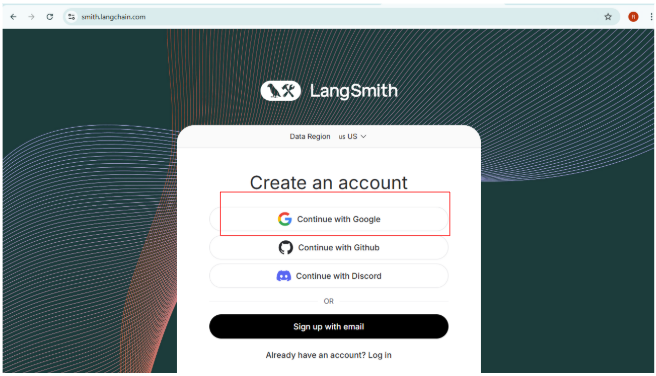

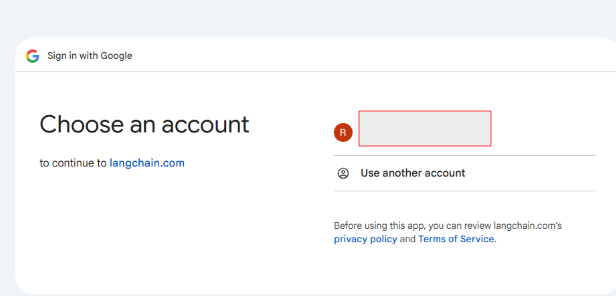

<font color=Magenta>**Proceed**</font> – Click **"Continue"** to move forward.

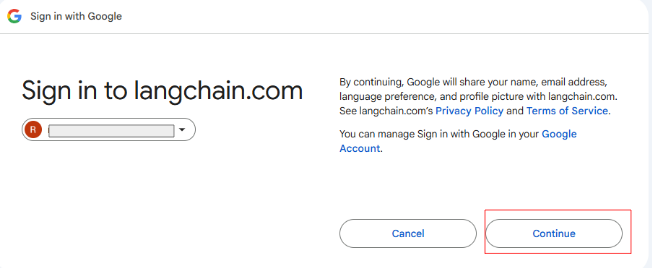

<font color=Magenta>**Start Setup**</font> – Click **"Get Started"** on the next screen.

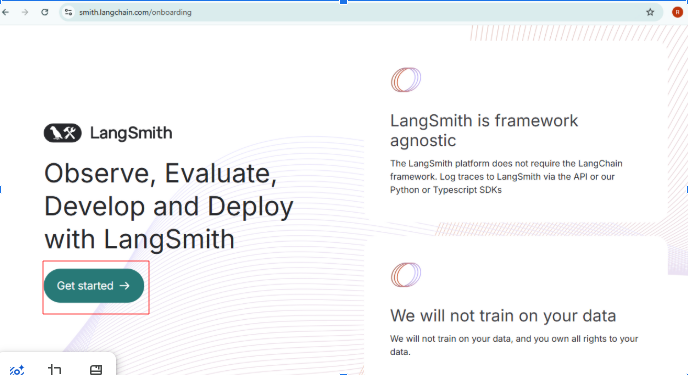

<font color=Magenta>**Generate API Key**</font> – Select **"Generate API"** to create your LangSmith API key.

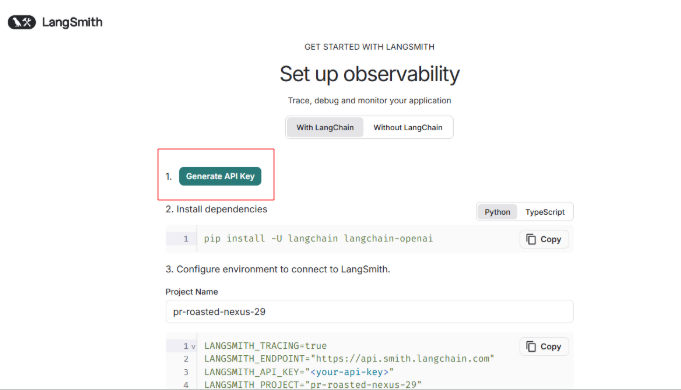

<font color=Magenta>**Copy Your API Key**</font> – Click the **red box icon** to copy your API key.

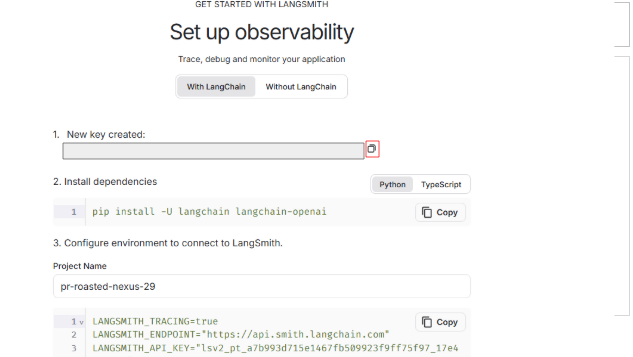

<font color=Magenta>**Save It**</font> – **Store the API key** securely, as you'll need it for authentication.

Now **click** on **"Skip for now"** at the bottom

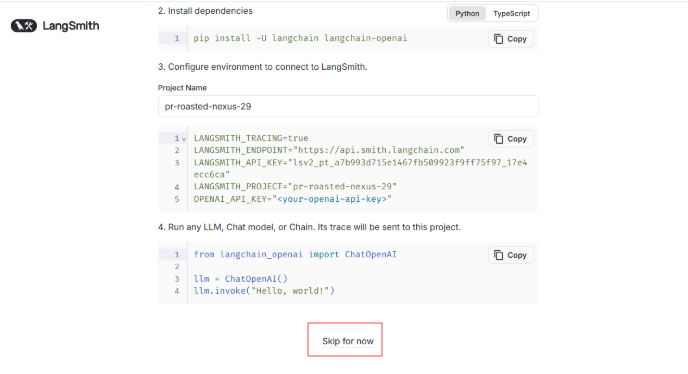

##<font color=blue>**Why Use @traceable in all chains used in the workflow?**

The @traceable(name="give your name") decorator is used to integrate LangSmith’s tracing and observability into a function or tool or chain. It helps track, monitor, and log the execution of the function, making debugging and performance analysis more efficient.

##<font color=blue>We will apply @traceable(name="use appropriate name") to all previously used chains


In [59]:
class CustomerStateV2(BaseModel):
    email: Optional[str] = None
    name: Optional[str] = None
    interests: Optional[str] = None
    email_found: bool = False
    customer_id: Optional[str] = None
    expanded_search: List[str] = []
    search_results: List[Dict[str, str]] = []
    credible_urls: List[Dict[str, str]] = []
    max_results: int = 7
    filtered_urls: List[Dict[str, str]] = []
    info: List[Dict[str, str]] = Field(default_factory=list)


# 🔹 Initialize SQL Agent with System Message
@traceable(name="SQL Agent")
def setup_sql_agent():
    db = SQLDatabase.from_uri("sqlite:///customer.db")

    system_message = """You are an AI-powered SQL assistant. Your role is to retrieve or insert structured data into the database efficiently and accurately. And return no result found if not able to retrieve data."""

    # Define SQL Query Tool
    sql_tool = QuerySQLDataBaseTool(db=db)

    # Initialize agent with system message
    sql_agent = initialize_agent(
        tools=[sql_tool],
        llm=llm_low,
        agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION,
        verbose=True,
        memory=ConversationBufferMemory(),
        system_message=system_message.strip()  # Pass system message to agent
    )

    return sql_agent

@traceable(name="Ask Email")
def ask_email(state: CustomerStateV2):
    """Retrieve email from state or prompt user if missing."""
    if not state.email:
        state.email = input("Enter your email ID: ").strip().lower()
    return {"email": state.email}

@traceable(name="Check Email")
def check_email(state: CustomerStateV2):
    """
    Queries the database for customer details using the provided email ID.
    Extracts ID, Name, Email, and Interests. If no result is found, email_found is set to False.
    """
    query = f"""
    Extract ID, Name, Email, and Interests information from the database for the email ID '{state.email}'.
    Always return responses with the following fields:
    - ID
    - Name
    - Email
    - Interests
    return no result found if not able to retreive data
    """

    # Execute query and strip result
    sql_agent = setup_sql_agent()
    result = sql_agent.run(query)

    # Early exit if no result found
    match = re.search(r"\bno\s+(result|results|record|records)\b", result, re.IGNORECASE)

    if match :
        state.email_found = False
        return {"email_found": False}
    interests_match = re.search(r"Interests:\s*(.+)", result)
    interests = [i.strip() for i in interests_match.group(1).split(",")] if interests_match else []

    # Extract email first
    email_match = re.search(r"Email:\s*([\w\.-]+@[\w\.-]+)", result)

    # Only proceed if we found a valid email
    email = email_match.group(1)

    # Extract interests
    interests_match = re.search(r"Interests:\s*(.+)", result)
    interests = [i.strip() for i in interests_match.group(1).split(",")] if interests_match else []

    try:
        # Extract name
        name_match = re.search(r"Name:\s*(.+)", result)
        name = name_match.group(1).strip() if name_match else None

        # Update state
        state.name = name
        state.interests = ', '.join(interests)
        state.email_found = True

        return {
            "email_found": True,
            "name": state.name,
            "interests": state.interests
        }

    except (json.JSONDecodeError, TypeError) as e:
        logging.error(f"Failed to parse customer data: {result} - Error: {str(e)}")
        state.email_found = False
        return {"email_found": False}

# Ask for name and interests if email not found, generate customer id and add in database
@traceable(name="Ask and Add Data in Database")
def ask_and_add_details(state: CustomerStateV2):
  # Generate a unique customer ID
    def generate_customer_id():
        return str(uuid.uuid4())[:10].upper()
    print("Your email is not in the database.")
    if not state.name:
       name = input("Enter your name: ").strip()
    else:
      name=state.name
    customer_id = generate_customer_id()

    while True:
        if not state.interests:
          interests = input(f"Select at least one interest (comma-separated): ").strip()
        else:
          interests=state.interests
        embed_interests = [i.strip() for i in interests.split(",")]
        if embed_interests:
            break
        print("❌ Please Enter at least one interest.")

    query = f"""INSERT INTO customers (customer_id, name, email, interests)
                VALUES ('{customer_id}', '{name}', '{state.email}', '{embed_interests}')"""
    sql_agent = setup_sql_agent()

    sql_agent.run(query)

    return {"email_found": True, "customer_id": customer_id, "name": name, "interests": interests}

# Show interests
@traceable(name="Show Interest")
def show_interests(state: CustomerStateV2):
    interests_str = state.interests
    return {"message": f"Hello {state.name}, your interests are {interests_str}."}



@traceable(name="Forming Queries to search interest based news")
def expand_search_queries(state: CustomerStateV2):
    """
    Use the core LLM to expand each user interest into a related search query.
    """
    print("---EXPAND SEARCH QUERIES---")


    system_prompt = f"""You are an expert news analyst specializing in crafting precise search queries to retrieve the most recent, up-to-date information.
            Your task is to generate one **relevant and time-sensitive** search query for each provided interest, ensuring the results focus on **breaking news, trending topics, or recent developments** only.

            - Do **not** include any specific year in the query.
            - Format queries to prioritize **current news** while avoiding outdated information.
            - Ensure the queries remain natural and relevant without relying on explicit date mentions."""


    expanded_queries = []
    mid_interest = state.interests
    interests = mid_interest.split(', ')
    for interest in interests:
        prompt = f"Generate one search query related to: '{interest}'"

        response = llm_low.invoke(
            [
                SystemMessage(content=system_prompt),
                HumanMessage(content=prompt)
            ]
        )

        query = response.content.strip()
        if query:
            expanded_queries.append(query)

    print("Expanded Search Queries:\n", expanded_queries)

    return {"expanded_search": expanded_queries}

@traceable(name="Clean Text")
def clean_text(text):
    # Remove special characters and extra whitespace
    cleaned = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return ' '.join(cleaned.split())

@traceable(name="Searching news for interest queries")
def get_duckduckgo_results(state: CustomerStateV2):
    print("---GETTING DUCKDUCKGO RESULTS---")
    search_results = []

    for query in state.expanded_search:
        # Clean both query
        clean_query = clean_text(query)

        # Skip if either is empty after cleaning
        if  not clean_query:
            print(f"Skipping invalid pair: { query}")
            continue

        print(f"🔍 Searching for: {clean_query}")

        with DDGS() as ddgs:
          while len(search_results) < 5:
            results = list(ddgs.news(clean_query, max_results=state.max_results))
            print(f"Raw Response for '{clean_query}': {results}")

            if not results or any("google.com" in r.get("url", "") for r in results):
                print(f"⚠️ Warning: Potential API issue or DuckDuckGo blocking request for '{clean_query}'.")
                continue

            search_results.extend(results)

            wait_time = random.uniform(2, 5)
            print(f"⏳ Waiting {wait_time:.2f} seconds before next request...")
            time.sleep(wait_time)

    print(search_results)
    return {"search_results": search_results}
@traceable(name="Filter urls based on interest")
def filter_urls(state: CustomerStateV2):
    """
    Filters URLs based on user interests and includes the associated body content in the output.
    """
    print("---FILTER RELEVANT URLS---")

    urls = []
    body_map = []  # Mapping of URL to its body content

    for result in state.search_results:
        urls.append(result['url'])
        body_map.append(result['body'])

    # Create the prompt with properly formatted URLs
    prompt = (
        "Identify and retain only the URLs that are relevant to one or more of the user's interests from the following list:\n\n"
        f"User Interests: {', '.join(state.interests)}\n\n"
        "URLs to filter:\n"
        + "\n".join(urls) + "\n\n"
        "Return only a list of relevant URLs without any explanation."
    )

    system_prompt = (
        "You are an expert in filtering search results. Your task is to extract only the URLs that match at least one of the user's interests, ensuring relevance to their request."
    )

    response = llm_low.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=prompt)
    ])

    # Clean the response by removing brackets and quotes
    filtered_results = response.content.strip()
    filtered_results = filtered_results.replace('[', '').replace(']', '').replace("'", '')
    filtered_results = [url.strip() for url in filtered_results.split('\n') if url.strip()]

    # Create output with URLs and associated body content
    filtered_urls = [{"url": filtered_results[i], "body": body_map[i]} for i in range(len(filtered_results))]
    state.filtered_urls=filtered_urls
    return {"filtered_urls": filtered_urls}
@traceable(name="Analyze Authenticity")
def analyze_news_url(state: CustomerStateV2):
    """Asks GPT to analyze if a URL is trustworthy."""
    print("---FILTER TRUSTWORTHY URLS---")
    urls = []
    body_map = []  # Mapping of URL to its body content

    for result in state.filtered_urls:
        urls.append(result['url'])
        body_map.append(result['body'])

    system_prompt = """You are a news credibility expert. Analyze if the given news URL belongs to a trustworthy source based on safety standards."""

    prompt = (
    "Analyze the credibility of the following news sources. "
    "Identify which URLs are trustworthy.\n\n"
    "URLs to evaluate:\n"
    + "\n".join(urls) +
    "\n\nReturn only a list of credible URLs without any explanation.")

    response = llm_low.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=prompt) ])
    # Clean the response by removing brackets and quotes
    credible_results = response.content.strip()
    credible_results = credible_results.replace('[', '').replace(']', '').replace("'", '')
    credible_results = [url.strip() for url in credible_results.split('\n') if url.strip()]

    # Create output with URLs and associated body content
    credible_urls = [{"url": credible_results[i], "body": body_map[i]} for i in range(len(credible_results))]
    print(credible_urls)
    return {"credible_urls": credible_urls}

@traceable(name="Extract URLs")
def extract_url_list(addable_dict: AddableValuesDict):
    # Extract URLs and content from the 'credilbe_url' section
    return [{"url": credible_url.get("url", ""), "content": credible_url.get("content", "")}
            for credible_url in addable_dict.get("credible_urls", [])]

@traceable(name="Generate Url")
def url_generation_with_agent(email: str, name: str = None, interests: str = None):


    initial_state = CustomerStateV2(email=email, name=name, interests=interests)

    # Initialize LangGraph workflow
    workflow = StateGraph(state_schema=CustomerStateV2)

    # Add nodes
    workflow.add_node("ask_email", ask_email)
    workflow.add_node("check_email", check_email)
    workflow.add_node("ask_and_add_details", ask_and_add_details)
    workflow.add_node("show_interests", show_interests)
    workflow.add_node("expand_search_queries", expand_search_queries)
    workflow.add_node("get_duckduckgo_results", get_duckduckgo_results)
    workflow.add_node("filter_urls", filter_urls)
    workflow.add_node("analyze_news_url", analyze_news_url)
    workflow.add_node("print_url", print_url)

    # Define Workflow Transitions
    workflow.set_entry_point("ask_email")
    workflow.add_edge("ask_email", "check_email")

    workflow.add_conditional_edges(
        "check_email",
        lambda result: "show_interests" if result.email_found else "ask_and_add_details"
    )

    workflow.add_edge("ask_and_add_details", "show_interests")
    workflow.add_edge("show_interests", "expand_search_queries")
    workflow.add_edge("expand_search_queries", "get_duckduckgo_results")
    workflow.add_edge("get_duckduckgo_results", "filter_urls")
    workflow.add_edge("filter_urls", "analyze_news_url")
    workflow.add_edge("analyze_news_url", "print_url")

    # Set workflow finish point instead of undefined `END`
    workflow.set_finish_point("print_url")

    # Compile and execute the workflow
    graph = workflow.compile()

    # Ensure langgraph_config is defined, or remove it
    output = graph.invoke(initial_state)

    # Extract URLs from output
    if "extract_url_list" in globals():
        final_output = extract_url_list(output)
    else:
        final_output = []

    formatted_results = [f"{i}. {result['url']}\n" for i, result in enumerate(final_output, 1)]

    return "\n".join(formatted_results)


##<font color=blue>**LangSmith Tracing Setup**



In [60]:
from langsmith import Client
from langsmith.run_trees import RunTree
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = "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" #Use your Langsmith api here
os.environ["LANGCHAIN_PROJECT"] = "LanggraphAgent"

In [61]:
# Initialize LangSmith client (ensure your API key is set)
langsmith_client = Client(api_key=os.environ["LANGCHAIN_API_KEY"])

In [62]:
os.environ["LANGCHAIN_API_KEY"]

'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'

**Function to add a project in langsmith_client if does not exist**

In [63]:
def get_or_create_project(client, project_name):
    try:
        # Try to list project first
        client.read_project(project_name=project_name)
        print(f"✅ Project '{project_name}' already exists")
        return True
    except Exception as e:
        if f"Project {project_name} not found" in str(e):
            print(f"🚀 Creating new project '{project_name}'...")
            client.create_project(project_name=project_name)
            print(f"✅ Project '{project_name}' created successfully!")
            return True
        print(f"❌ Error: {str(e)}")
        return False

In [64]:
get_or_create_project(langsmith_client, os.environ["LANGCHAIN_PROJECT"])

True

##<font color=blue>**Function to trace the Langgraph workflow with Langsmith**

In [65]:
def run_with_tracing(email, name=None, interests=None):
    """Tracks execution of `url_generation_with_agent` using LangSmith RunTree."""
    run_tree = None
    try:
        # Initialize tracking
        run_tree = RunTree(
            name="Trace URL",
            run_type="chain",
            client=langsmith_client,
            project_name="LanggraphAgent",
            inputs={"email": email, "name": name, "interests": interests}
        )
        run_tree.post()

        # Execute the main function
        result = url_generation_with_agent(email, name, interests)

        # Log successful completion and wait for sync
        run_tree.end(outputs={"result": result})
        run_tree.wait()  # Wait for all futures to complete
        run_tree.patch()  # Force sync with LangSmith API

        return result

    except Exception as e:
        # Log error with detailed information
        if run_tree:
            run_tree.end(
                error=str(e),
                metadata={"exception_type": type(e).__name__}
            )
            run_tree.patch()  # Sync error state
        raise

    finally:
        # Ensure cleanup with explicit status check
        if run_tree and not run_tree.end_time:
            run_tree.end(error="Unknown error, execution did not complete.")
            run_tree.patch()  # Sync final state

##<font color=blue>**Trace**

In [66]:
test_data = {
    "info": [
        {"url": "https://www.economist.com", "summary": "Economic trends"},
        {"url": "https://www.cnn.com", "summary": "Political news"}
    ]
}
CustomerStateV2(**test_data)

CustomerStateV2(email=None, name=None, interests=None, email_found=False, customer_id=None, expanded_search=[], search_results=[], credible_urls=[], max_results=7, filtered_urls=[], info=[{'url': 'https://www.economist.com', 'summary': 'Economic trends'}, {'url': 'https://www.cnn.com', 'summary': 'Political news'}])

In [67]:
result1=run_with_tracing("alice.6eb33c45-5@gmail.com")


In [71]:
result2=run_with_tracing("max@example.com","max","Langgraph Agent")

In [72]:
result2

'1. https://siliconangle.com/2025/10/20/ai-agent-tooling-provider-langchain-raises-125m-1-25b-valuation/\n'

##<font color=blue>**Steps to observe on Langsmith**

<font color=Magenta>**Go to LangSmith**</font> – Click on the provided [Langsmith Link](https://smith.langchain.com/)

<font color=Magenta>**Open Tracing Project**</font> – **Select "Tracing Project** from the dashboard.

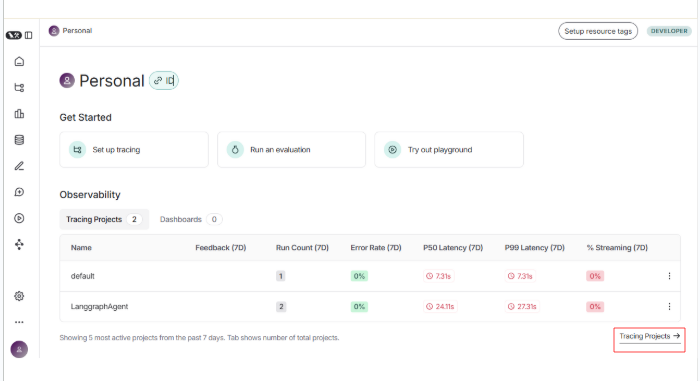

<font color=Magenta>**Access Your Agent**</font> – Click on "**LanggraphAgent**" (highlighted in the red box).

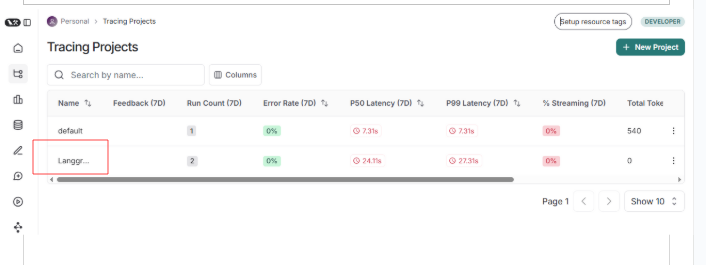

<font color=Magenta>**View Tracing Details**</font> – Click on **"Trace URL"** to see the recorded observations of inputs and outputs.

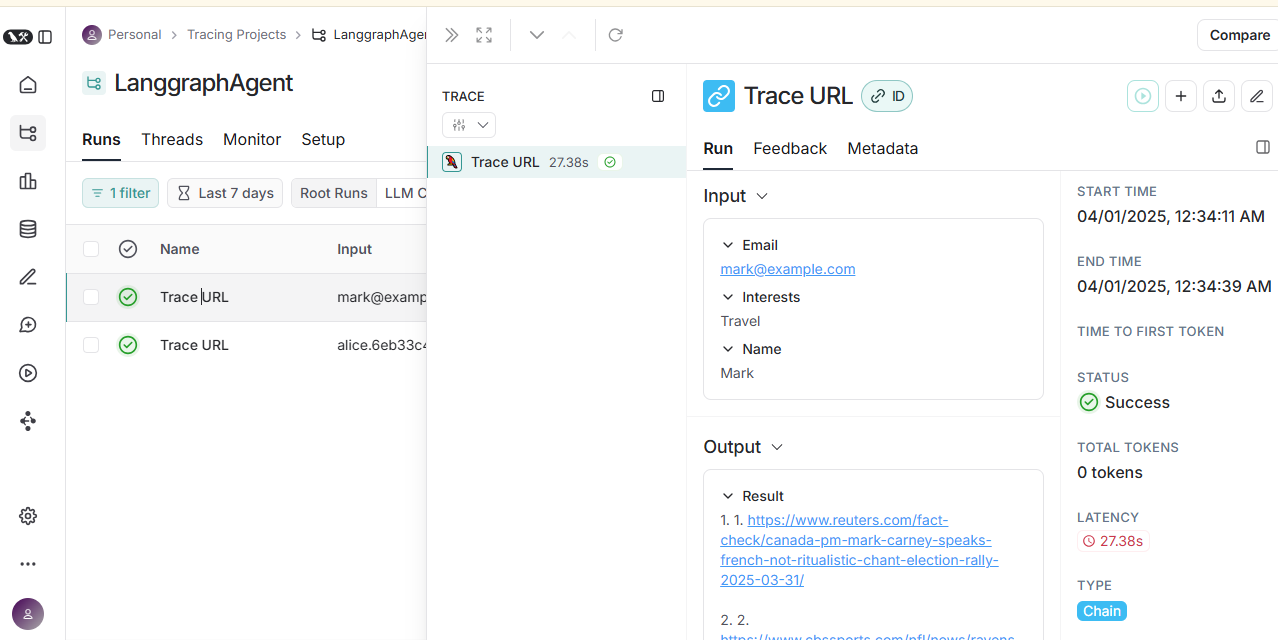

##<font color=blue>**Summarizing Content Based on User Interests**</font>

<font color=blue>**Text Summarization Function**</font>

**Function Explanation:**

This function generates a concise summary of the provided content, focusing on the user’s specified interests.

Extracts key information relevant to the given interests.

Uses a system prompt to instruct the LLM to act as a summarization expert.

Constructs a user prompt that requests a summary limited to 50 words.

Sends both the system message and user message to the LLM for processing.

Retrieves and cleans the LLM's response, ensuring a concise and relevant summary.

Returns the final summarized content for further use or display.

In [73]:
def summarize_content(interests: str, content: str):
    """
    Summarize the content using the core LLM.

    Args:
        query (str): The user's query
        content (str): The content to be summarized

    Returns:
        str: The summarized content
    """
    print("---SUMMARIZE CONTENT---")

    system_prompt = """You are an expert in summarization. Your task is to extract and condense key information based on a given interest."""
    prompt = f"Summarize the following content, focusing only on information relevant to these interests: {interests}.\n\nContent:\n{content}\n\n Limit the summary to 50 words."

    response = llm_high.invoke(
        [
            SystemMessage(content=system_prompt),
            HumanMessage(content=prompt)
        ]
    )
    return response.content.strip()

<font color=blue>**Grammar Correction Using LLM**</font>

**Function Explanation:**

This function utilizes an LLM to check and correct grammatical errors while preserving the original meaning of the text.

Uses a system prompt to instruct the model to act as an expert in English grammar and writing.

Constructs a user prompt requesting correction of spelling, grammar, and punctuation errors.

Sends both the system message and user message to the LLM for processing.

Extracts and cleans the corrected response, ensuring the output contains only the corrected text.

Returns the grammatically improved version of the input text.

In [74]:
def correct_grammar(text):
    """
    Uses GPT-4 to check and correct grammar in the input text.

    Args:
        text (str): The original text with potential grammatical errors.

    Returns:
        str: A grammatically correct version of the text.
    """
    system_prompt = "You are an expert in English grammar and writing. Your task is to correct any grammatical, spelling, or punctuation mistakes in the given text while preserving the original meaning."

    user_prompt = f"Correct the following text:\n\n{text}\n\nReturn only the corrected text, without explanations."

    response = llm_low.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ])

    return response.content.strip()

<font color=blue>**Extract and Summarize Website Content**</font>

Function Explanation:

This function retrieves content from credible URLs, extracts meaningful information, and summarizes it based on user interests.

Fetches webpage content using requests with custom headers to simulate a real browser request.

Parses the HTML using BeautifulSoup, removing unnecessary <script> and <style> elements.

Extracts relevant article content, prioritizing structured elements such as <article> and .article-body.

Checks content length—if it's too short, falls back on previously filtered content.

Summarizes extracted content using the summarize_content function, ensuring relevance to user interests.

Applies grammar correction via correct_grammar to refine readability.

Handles request failures gracefully by logging errors and defaulting to the previously stored content.

Returns a structured dictionary containing URLs and their refined summaries for further processing.

In [75]:
def summarize_check_site_content(state: CustomerStateV2):
    """
    Fetch and return the content of the given URL using requests & BeautifulSoup.
    """
    print("---FETCH SITE CONTENT---")
    extracted_info = []

    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
                      '(KHTML, like Gecko) Chrome/74.0.3729.169 Safari/537.36',
        'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8',
        'Accept-Language': 'en-US,en;q=0.5',
        'Connection': 'keep-alive',
        'Upgrade-Insecure-Requests': '1'
    }
    pattern = r"https?://\S+"
    for result in state.credible_urls:
        initial = result['url']
        url=re.search(pattern,initial).group(0)
        original_body = result['body']  # Get the body content from the filtering step

        try:
            response = requests.get(url, headers=headers, timeout=15)
            response.raise_for_status()

            # Parse HTML content
            soup = BeautifulSoup(response.text, 'html.parser')

            # Remove all script and style elements
            for script in soup(["script", "style"]):
                script.decompose()

            # Try extracting content
            content = None
            if soup.find('article'):
                content = soup.find('article').get_text()
            elif soup.find('div', class_='article-body'):
                content = soup.find('div', class_='article-body').get_text()
            if content:
                word_count = len(content.split())  # Splitting content into words and counting them
                if word_count > 20:
                    content = summarize_content(state.interests, content)
                    content = correct_grammar(content)
                    extracted_info.append({"url": url, "content": content})
                else:
                    original_body = correct_grammar(original_body)
                    extracted_info.append({"url": url, "content": original_body})
            else:
                original_body = correct_grammar(original_body)
                extracted_info.append({"url": url, "content": original_body})

        except requests.exceptions.RequestException as e:
            print(f"Failed to fetch {url}: {str(e)}")
            original_body = correct_grammar(original_body)
            extracted_info.append({"url": url, "content": original_body})  # Use the existing body in case of failure

    return {"info": extracted_info}

In [76]:
def print_output(state: CustomerStateV2):
    print("---FINAL OUTPUT---")
    for result in state.info:
        print(result['url'])
        print("\n")  # Print two blank lines
        print(result['content'])
        print("\n")   # Ensure info is correctly passed in state

In [77]:
# Initialize the customer state object to store user details and workflow progress
initial_state = CustomerStateV2()

# Initialize LangGraph workflow with the defined state schema
workflow = StateGraph(state_schema=CustomerStateV2)

# Step 1: Collect user email and preferences
workflow.add_node("ask_email", ask_email)  # Prompt user for their email
workflow.add_node("check_email", check_email)  # Check if the email exists in the database
workflow.add_node("ask_and_add_details", ask_and_add_details)  # Collect name and interests if email is not found
workflow.add_node("show_interests", show_interests)  # Display the user's interests

# Step 2: Expand search queries based on user interests
workflow.add_node("expand_search_queries", expand_search_queries)  # Generate refined search queries

# Step 3: Fetch search results from DuckDuckGo
workflow.add_node("get_duckduckgo_results", get_duckduckgo_results)  # Retrieve news articles based on search queries

# Step 4: Filter URLs to keep only relevant ones
workflow.add_node("filter_urls", filter_urls)  # Select URLs relevant to the user's interests

# Step 5: Filter URLs to keep only authentic ones
workflow.add_node("analyze_news_url", analyze_news_url)  # Check the credibility of news sources

# Step 6: Fetch and summarize site content
workflow.add_node("summarize_check_site_content", summarize_check_site_content)  # Extract and summarize article content

# Step 7: Print final output
workflow.add_node("print_output", print_output)  # Display the final summarized information

# Define Workflow Transitions
workflow.set_entry_point("ask_email")  # Start the workflow by asking for email

# Transition from asking email to checking if it's in the database
workflow.add_edge("ask_email", "check_email")

# If the email is found, show interests; otherwise, ask for details and then show interests
workflow.add_conditional_edges(
    "check_email",
    lambda result: "show_interests" if result.email_found else "ask_and_add_details"
)

# After collecting details, display user interests
workflow.add_edge("ask_and_add_details", "show_interests")

# Expand search queries based on the collected interests
workflow.add_edge("show_interests", "expand_search_queries")

# Fetch search results using DuckDuckGo
workflow.add_edge("expand_search_queries", "get_duckduckgo_results")

# Filter search results to keep only relevant URLs
workflow.add_edge("get_duckduckgo_results", "filter_urls")

# Analyze news URLs to ensure credibility
workflow.add_edge("filter_urls", "analyze_news_url")

# Fetch and summarize content from the verified news sources
workflow.add_edge("analyze_news_url", "summarize_check_site_content")

# Print the final output after summarizing content
workflow.add_edge("summarize_check_site_content", "print_output")

# Set the final output step as the end of the workflow
workflow.add_edge("print_output", END)

# Compile and execute the workflow
graph = workflow.compile()

Email ids to use : alice.6eb33c45-5@gmail.com

For Email Id in Database

response = graph.invoke(initial_state, langgraph_config)

For Email Id not in database

In [78]:
response = graph.invoke(initial_state, langgraph_config)

Enter your email ID: alice.6eb33c45-5@gmail.com


##<font color=blue>**Final Function that we will deploy without Input Function**

In [79]:
import logging
import sys
import os
import builtins

In [80]:
def extract_info_list(addable_dict: AddableValuesDict):
    # Extract URLs and content from the 'info' section
    return [{"url": info.get("url", ""), "content": info.get("content", "")}
            for info in addable_dict.get("info", [])]

In [82]:
def chat_with_agent(email: str,name: str=None,interests:str=None):
    """Starts the workflow with a provided email."""
    # Ensure email is passed correctly to CustomerState
    # Create an instance of CustomerState with email
    def suppress_logs():
        """Disables all logging, print statements, and standard output."""
        logging.basicConfig(level=logging.WARNING, force=True)

        # Silence specific noisy loggers
        for noisy_logger in ["sql agent", "duckduck go search"]:
            logging.getLogger(noisy_logger).setLevel(logging.ERROR)

        # Redirect stdout and stderr to prevent any unwanted print output
        sys.stdout = open(os.devnull, "w")
        sys.stderr = open(os.devnull, "w")

        # Disable print statements
        builtins.print = lambda *args, **kwargs: None

    # Call this function at the start to suppress logs
    suppress_logs()
    initial_state = CustomerStateV2(email=email,name=name,interests=interests)

    # Initialize workflow
    workflow = StateGraph(state_schema=CustomerStateV2)

    # Add nodes
    # Step 1: Collect user email and preferences
    workflow.add_node("ask_email", ask_email)
    workflow.add_node("check_email", check_email)
    workflow.add_node("ask_and_add_details", ask_and_add_details)
    workflow.add_node("show_interests", show_interests)

    # Step 2: Expand search queries based on user interests
    workflow.add_node("expand_search_queries", expand_search_queries)

    # Step 3: Fetch search results from DuckDuckGo
    workflow.add_node("get_duckduckgo_results", get_duckduckgo_results)

    # Step 4: Filter URLs to keep only relevant ones
    workflow.add_node("filter_urls", filter_urls)

    # Step 5: Filter url to keep only authentic ones
    workflow.add_node("analyze_news_url", analyze_news_url)

    # Step 6: Fetch and summarize site content
    workflow.add_node("summarize_check_site_content", summarize_check_site_content)


    # Step 7: Print output
    workflow.add_node("print_output", print_output)

    # Define Workflow Transitions
    workflow.set_entry_point("ask_email")
    workflow.add_edge("ask_email", "check_email")
    workflow.add_conditional_edges(
        "check_email",
        lambda result: "show_interests" if result.email_found else "ask_and_add_details"
    )
    workflow.add_edge("ask_and_add_details", "show_interests")

    # Expand search queries based on user interests
    workflow.add_edge("show_interests", "expand_search_queries")

    # Fetch search results using DuckDuckGo
    workflow.add_edge("expand_search_queries", "get_duckduckgo_results")

    # Filter out irrelevant URLs
    workflow.add_edge("get_duckduckgo_results", "filter_urls")

    # Filter out Fake url
    workflow.add_edge("filter_urls","analyze_news_url")
    # Fetch content from filtered URLs and summarize it
    workflow.add_edge("analyze_news_url", "summarize_check_site_content")

    # Print the final output after fetching content
    workflow.add_edge("summarize_check_site_content", "print_output")

    # Set the final output as the last step
    workflow.add_edge("print_output",END)

    graph = workflow.compile()
    # Start workflow execution with initial state
    output = graph.invoke(initial_state,langgraph_config)
    final_output=extract_info_list(output)
    formatted_results = []
    for i, result in enumerate(final_output, 1):
        formatted_results.append(f"{i}. {result['url']}\n\n{result['content']}\n\n")

    return "\n".join(formatted_results)

In [83]:
chat_with_agent("richa@example.com","Richa","Health")

'1. https://www.cbsnews.com/news/reproductive-health-trump-administration-hhs-cuts/\n\nThe closure of rural reproductive health clinics in Maine signals a crisis in U.S. reproductive care, exacerbated by cuts to Title X, Medicaid, and other health programs. This deterioration threatens access to essential services, increasing the risks of unplanned pregnancies and maternal health issues, particularly among underserved communities.\n\n'

##<font color=blue>**Deployment of Final Function to give news summary and url**

In [84]:
import gradio as gr

In [85]:
with gr.Blocks() as iface:
    gr.Markdown("## 🔍 AI-Powered News Fetcher")

    with gr.Tabs():
        with gr.Tab("For Existing Members"):
            gr.Markdown("Enter your email id.")
            with gr.Row():
                with gr.Column(scale=1):
                    email_input_wo = gr.Textbox(label="Enter your email id", placeholder="e.g., abc@example.com")

                    with gr.Row():
                        submit_button_wo = gr.Button("Submit", variant="primary")
                        cancel_button_wo = gr.Button("Cancel", variant="stop")

                with gr.Column(scale=2):
                    output_wo = gr.Textbox(label="Latest News", interactive=False)

            submit_button_wo.click(fn=chat_with_agent, inputs=email_input_wo, outputs=output_wo)
            cancel_button_wo.click(fn=lambda: "", inputs=[], outputs=output_wo)

        with gr.Tab("For New Members"):
            gr.Markdown("Enter an order number and your query.")
            with gr.Row():
                with gr.Column(scale=1):
                    email_input_g = gr.Textbox(label="Enter Your Email Id", placeholder="e.g., abc@example.com")
                    name_input_g = gr.Textbox(label="Enter Your Name", placeholder="e.g., Mark")
                    interest_input_g=name_input_g = gr.Textbox(label="Enter Your Interest seperated by commas ','", placeholder="e.g., Generative AI")

                    with gr.Row():
                        submit_button_g = gr.Button("Submit", variant="primary")
                        cancel_button_g = gr.Button("Cancel", variant="stop")

                with gr.Column(scale=2):
                    output_g = gr.Textbox(label="Latest News", interactive=False)

            submit_button_g.click(fn=chat_with_agent, inputs=[email_input_g, name_input_g,interest_input_g], outputs=output_g)
            cancel_button_g.click(fn=lambda: "", inputs=[], outputs=output_g)

# 🌍 Launch Gradio
iface.launch(share=True)

##<font color=blue>**Summary of Interest-Based News URL Retrieval and Summary generation Workflow:**</font>

Through a structured approach, we have successfully developed a workflow for retrieving and filtering news URLs based on user interests. Our key achievements include:

✅ <font color=Magenta>User Data Retrieval & Onboarding:</font> For existing users, fetch interest details based on the provided URL. For new users, collect email, name, and interests and securely store them in the database.

✅ <font color=Magenta>Search Query Expansion:</font> Enhanced user queries to retrieve more relevant search results based on specified interests.

✅ <font color=Magenta>Reliable Search Integration:</font> Implemented DuckDuckGo as the search engine to fetch unbiased and diverse news sources.

✅ <font color=Magenta>Relevance Filtering:</font> Applied AI-driven filtering to retain only the URLs aligned with user interests.

✅ <font color=Magenta>Credibility Assessment:</font> Evaluated news sources to exclude unreliable or misleading information, ensuring trustworthy content.

✅ <font color=Magenta>Final URL Extraction:</font> Compiled and displayed the most relevant and credible news URLs for the user.

###🔹<font color=blue> **Optional Content**</font>

✅ <font color=Magenta>Website Content Extraction & Summarization:</font> Fetched and parsed web content, removed unnecessary elements, and extracted meaningful text. Summarized content based on user interests while ensuring grammatical accuracy.

✅ <font color=Magenta>Grammar Correction:</font> Applied AI-based grammar refinement to ensure the summarized content is clear and well-structured.

✅ <font color=Magenta>Deployment:</font> Successfully deployed the workflow, ensuring efficient interest-based filtering, and the delivery of trustworthy news URLs and summaries to users.

At this stage, we have established an efficient, structured, and interest-driven workflow that retrieves, filters, and refines news content while ensuring an optimal user experience.